# Atelier ML — Analyse Comportementale Clientèle Retail
**Pipeline complet : Exploration → Préparation → Modélisation → Évaluation**

## ⚙️ ÉTAPE 0 — Configuration & Imports

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.utils import load_data, eda_summary, plot_missing_values, \
                      plot_churn_distribution, plot_correlation_heatmap, \
                      feature_engineering, drop_useless_features

from src.preprocessing import (
    clean_outliers, impute_numerical, impute_categorical,
    encode_features, remove_high_correlation,
    scale_features, split_and_save, full_preprocessing_pipeline
)

from src.train_model import (
    apply_pca, visualize_pca_2d,
    find_optimal_k, train_kmeans,
    train_logistic_regression, train_random_forest,
    evaluate_classifier, plot_feature_importance,
    train_regression, evaluate_regression
)

import joblib
import os
os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../data/train_test', exist_ok=True)

print('✅ Imports OK')

✅ Imports OK


## ÉTAPE 1 — Exploration des Données (EDA)

In [2]:
# Chargement
df_raw = load_data('../data/raw/retail_customers_COMPLETE_CATEGORICAL.csv')
eda_summary(df_raw)

✅ Données chargées : 4372 lignes, 52 colonnes
📊 RÉSUMÉ DES DONNÉES
Dimensions : (4372, 52)

Types de données :
int64      20
str        18
float64    14
Name: count, dtype: int64

Valeurs manquantes :
AvgDaysBetweenPurchases      79
Age                        1311
dtype: int64

Statistiques numériques :
         CustomerID      Recency    Frequency  MonetaryTotal  MonetaryAvg  \
count   4372.000000  4372.000000  4372.000000    4372.000000  4372.000000   
mean   15299.677722    92.047118     5.075480    1898.459701    28.839013   
std     1722.390705   100.765435     9.338754    8219.345141   127.323926   
min    12346.000000     1.000000     1.000000   -4287.630000 -4287.630000   
25%    13812.750000    17.000000     1.000000     293.362500    10.985960   
50%    15300.500000    50.000000     3.000000     648.075000    16.918616   
75%    16778.250000   143.000000     5.000000    1611.725000    23.542941   
max    18287.000000   374.000000   248.000000  279489.020000  3861.000000   

 

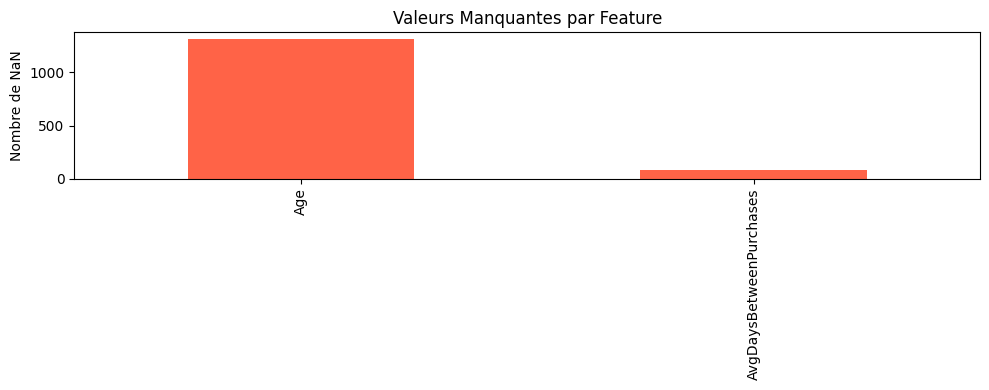

In [3]:
# Valeurs manquantes
plot_missing_values(df_raw, save_path='../reports/missing_values.png')

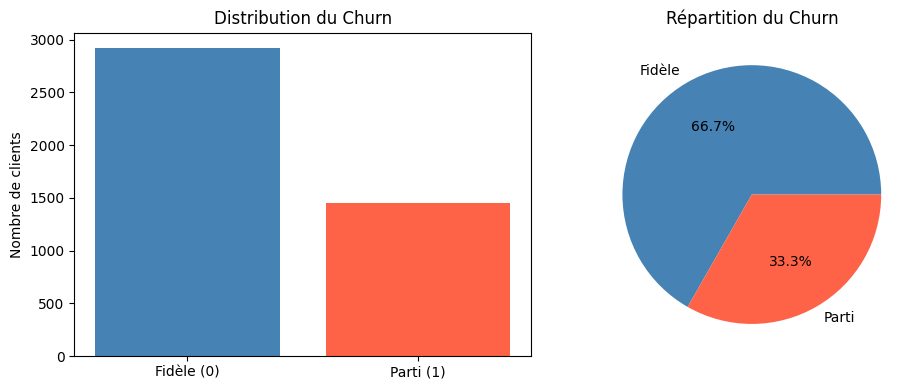

In [4]:
# Distribution de la variable cible
plot_churn_distribution(df_raw, save_path='../reports/churn_distribution.png')

In [5]:
# Valeurs aberrantes identifiées dans le cahier des charges
print('SupportTicketsCount :', sorted(df_raw['SupportTicketsCount'].dropna().unique()))
print('SatisfactionScore   :', sorted(df_raw['SatisfactionScore'].dropna().unique()))
print('MonetaryTotal min/max:', df_raw['MonetaryTotal'].min(), '/', df_raw['MonetaryTotal'].max())

SupportTicketsCount : [np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(999.0)]
SatisfactionScore   : [np.float64(-1.0), np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(99.0)]
MonetaryTotal min/max: -4287.63 / 279489.02



⚠️  Paires corrélées (|r| > 0.8) :
  Recency ↔ Churn : 0.859
  Frequency ↔ UniqueInvoices : 1.000
  MonetaryTotal ↔ TotalQuantity : 0.922
  MonetaryStd ↔ MonetaryMin : -0.967
  MonetaryStd ↔ MonetaryMax : 0.966
  MonetaryStd ↔ MinQuantity : -0.974
  MonetaryStd ↔ MaxQuantity : 0.973
  MonetaryMin ↔ MonetaryMax : -0.994
  MonetaryMin ↔ MinQuantity : 0.919
  MonetaryMin ↔ MaxQuantity : -0.916
  MonetaryMax ↔ MinQuantity : -0.916
  MonetaryMax ↔ MaxQuantity : 0.921
  MinQuantity ↔ MaxQuantity : -0.961
  UniqueProducts ↔ UniqueDescriptions : 1.000
  UniqueProducts ↔ TotalTransactions : 0.878
  UniqueDescriptions ↔ TotalTransactions : 0.880
  AvgProductsPerTransaction ↔ AvgLinesPerInvoice : 0.963
  NegativeQuantityCount ↔ CancelledTransactions : 1.000


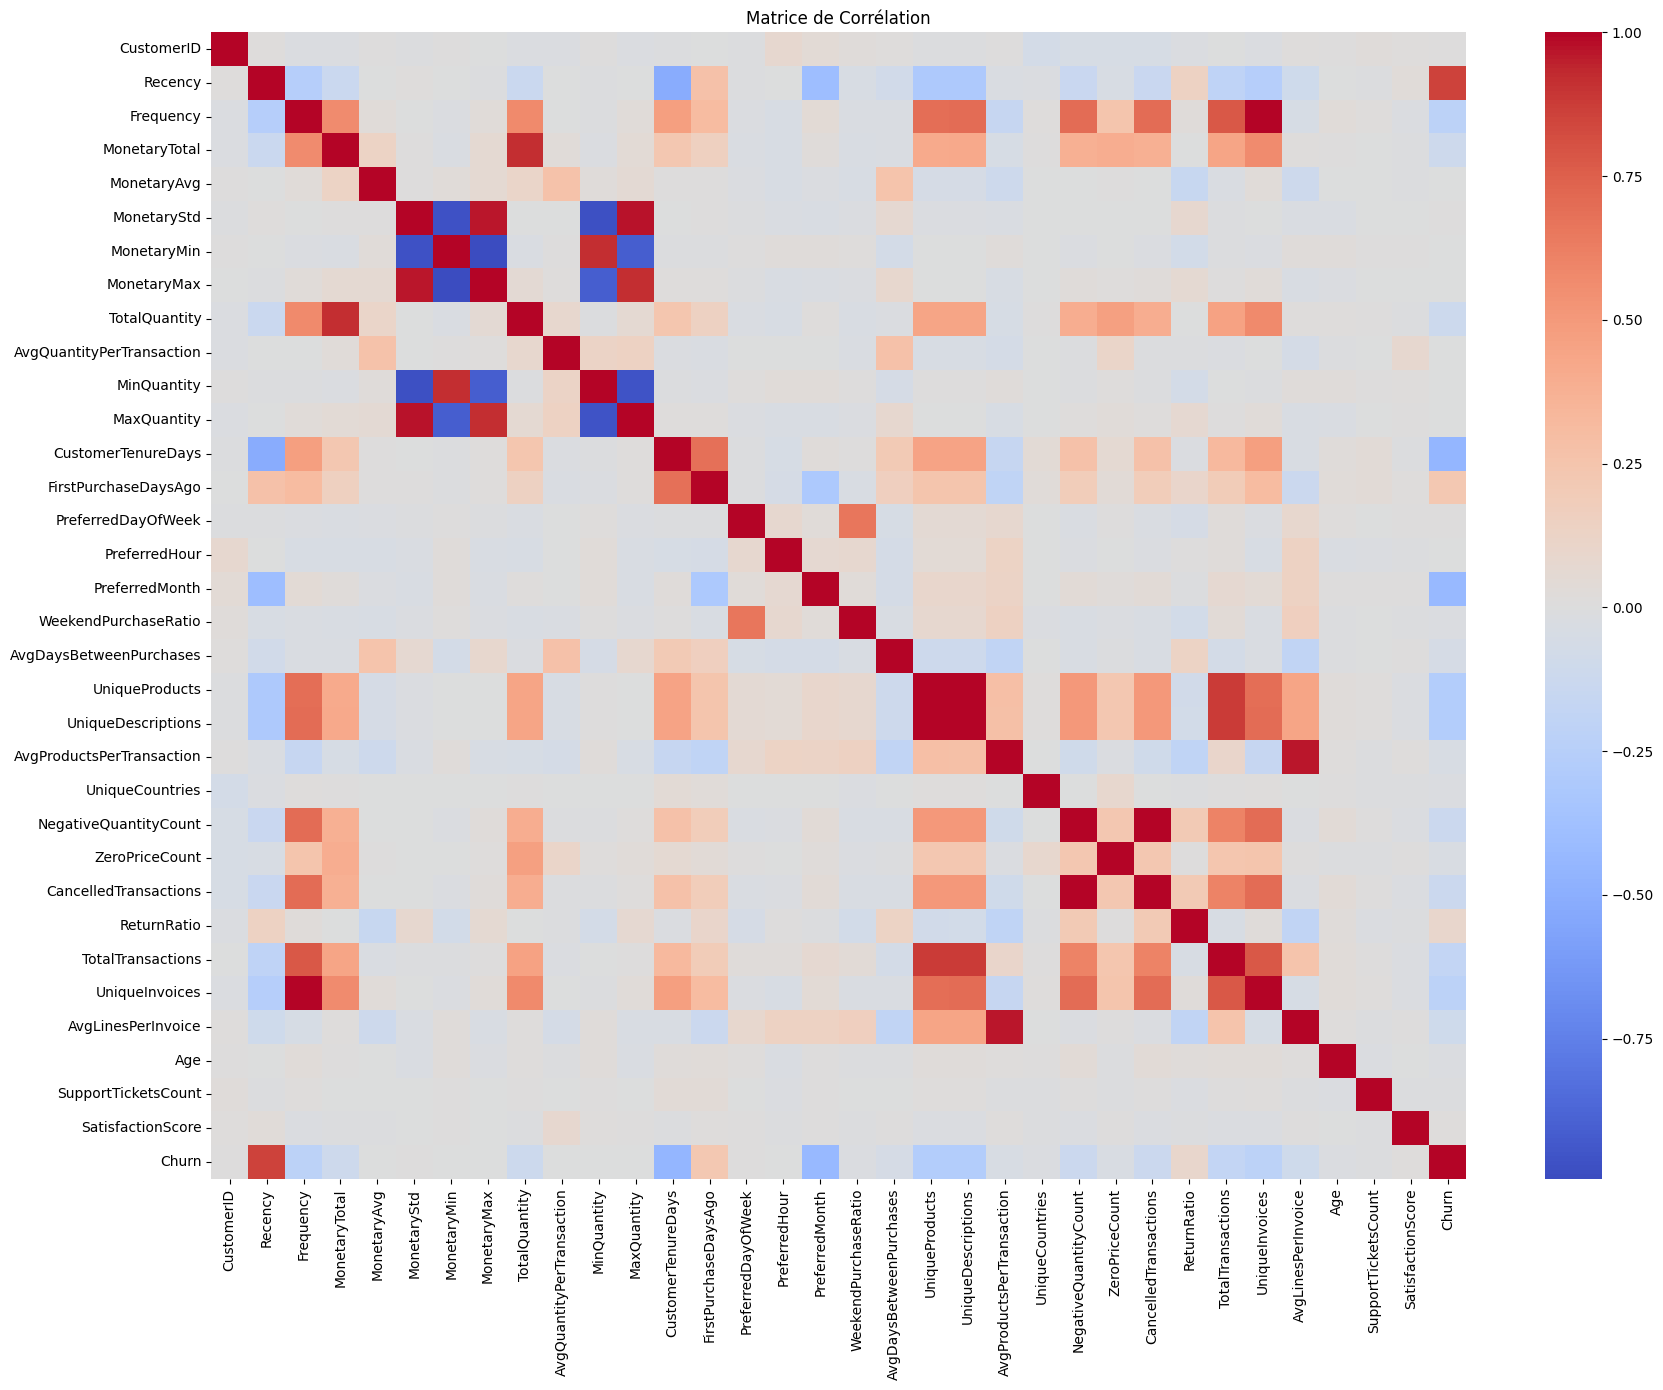

In [6]:
# Heatmap de corrélation
high_corr = plot_correlation_heatmap(df_raw, threshold=0.8, save_path='../reports/correlation_heatmap.png')

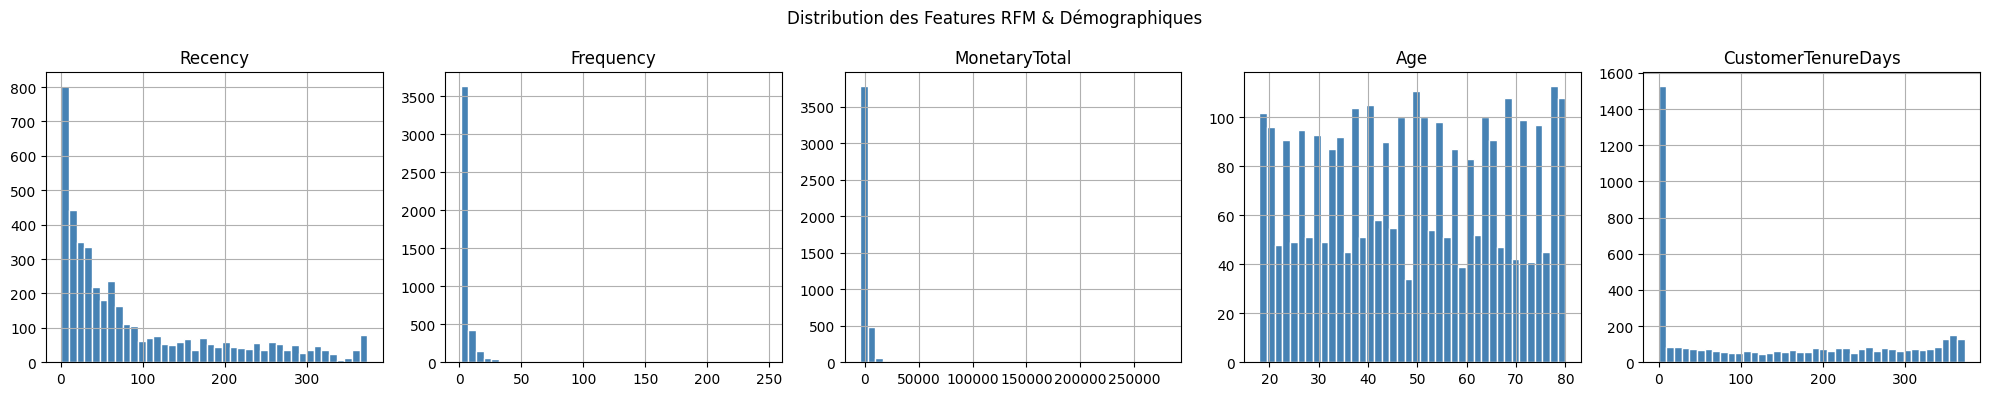

In [7]:
# Distributions des features numériques importantes
key_features = ['Recency', 'Frequency', 'MonetaryTotal', 'Age', 'CustomerTenureDays']
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, feat in zip(axes, key_features):
    df_raw[feat].hist(ax=ax, bins=40, color='steelblue', edgecolor='white')
    ax.set_title(feat)
plt.suptitle('Distribution des Features RFM & Démographiques')
plt.tight_layout()
plt.savefig('../reports/distributions.png')
plt.show()

## 🔧 ÉTAPE 2 — Prétraitement Complet

In [8]:
# Feature Engineering
df = feature_engineering(df_raw)

# Suppression des features inutiles
df = drop_useless_features(df)

# Pipeline de prétraitement
df_processed = full_preprocessing_pipeline(df)

# Sauvegarde
df_processed.to_csv('../data/processed/data_clean.csv', index=False)
print('✅ Données prétraitées sauvegardées')

✅ Feature Engineering : 60 colonnes après transformation
✅ Colonnes supprimées : ['CustomerID', 'NewsletterSubscribed', 'LastLoginIP', 'RegistrationDate']

🔧 PIPELINE DE PRÉTRAITEMENT
✅ Valeurs aberrantes corrigées.
✅ Imputation catégorielle par 'Inconnu' effectuée.
✅ Imputation (median) sur : ['AvgDaysBetweenPurchases', 'Age', 'SupportTicketsCount', 'SatisfactionScore']
✅ Encodage terminé. Dimensions : (4372, 87)
✅ Features supprimées (corrélation > 0.85) : ['MonetaryMax', 'MinQuantity', 'MaxQuantity', 'UniqueDescriptions', 'CancelledTransactions', 'TotalTransactions', 'UniqueInvoices', 'AvgLinesPerInvoice', 'PreferredTimeOfDay', 'LoyaltyLevel', 'CustomerType_Perdu', 'WeekendPreference_Weekend', 'ProductDiversity_Modéré', 'Country_FreqEnc']

✅ Prétraitement terminé. Shape final : (4372, 73)
✅ Données prétraitées sauvegardées


In [9]:
# Split Train/Test
X_train, X_test, y_train, y_test = split_and_save(
    df_processed, target='Churn', save_dir='../data/train_test'
)
print(f'X_train : {X_train.shape}, X_test : {X_test.shape}')

✅ Split effectué : train=3497, test=875
   Distribution churn train : {0: 2334, 1: 1163}
X_train : (3497, 72), X_test : (875, 72)


In [10]:
# Normalisation (après le split !)
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)
joblib.dump(scaler, '../models/scaler.pkl')
print('✅ Scaler sauvegardé')

✅ Normalisation StandardScaler appliquée.
✅ Scaler sauvegardé


## 🔬 ÉTAPE 3 — ACP (Réduction de Dimension)

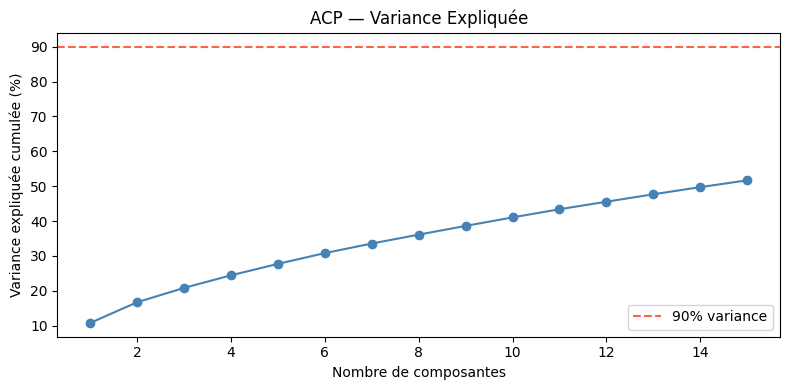

✅ ACP : 15 composantes → 51.7% de variance expliquée


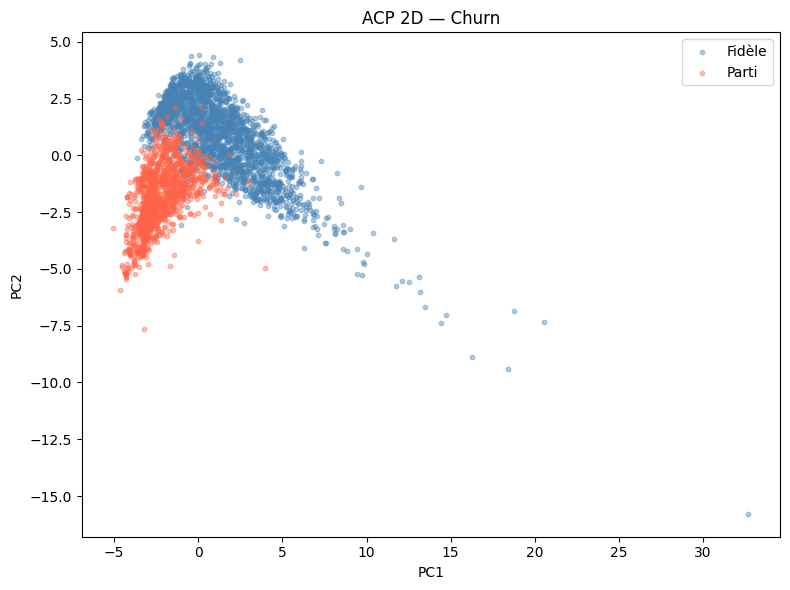

In [11]:
X_train_pca, X_test_pca, pca = apply_pca(
    X_train_scaled, X_test_scaled,
    n_components=15,
    save_path='../reports/pca_variance.png'
)
visualize_pca_2d(X_train_pca, y_train, save_path='../reports/pca_2d.png')

## 🔵 ÉTAPE 4 — Clustering K-Means

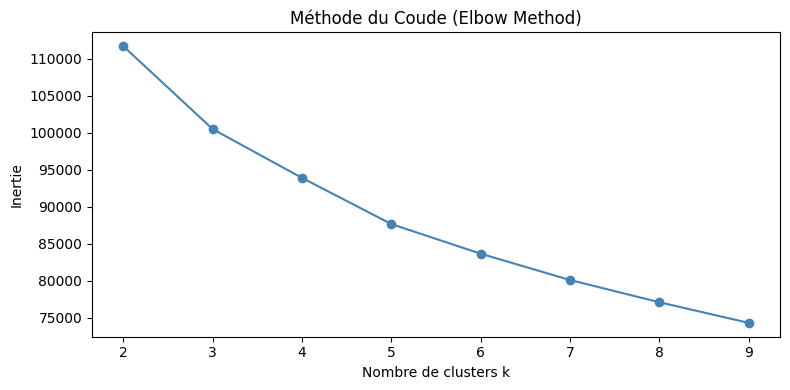

✅ K optimal suggéré : 3
✅ KMeans entraîné (4 clusters) — sauvegardé dans models/kmeans.pkl


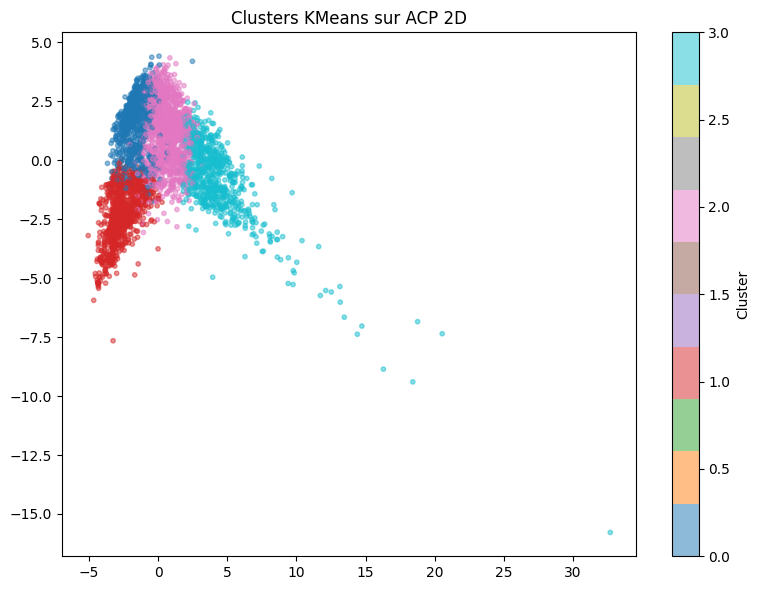

In [12]:
# Trouver le k optimal
optimal_k = find_optimal_k(X_train_pca, save_path='../reports/elbow.png')

# Entraîner KMeans
km, train_labels = train_kmeans(X_train_pca, n_clusters=4)

# Visualisation des clusters sur ACP 2D
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
                     c=train_labels, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_title('Clusters KMeans sur ACP 2D')
plt.tight_layout()
plt.savefig('../reports/clusters_pca.png')
plt.show()

In [13]:
# Profil des clusters (sur données originales)
X_train_copy = X_train.copy()
X_train_copy['Cluster'] = train_labels
X_train_copy['Churn'] = y_train.values

rfm_cols = ['Recency', 'Frequency', 'MonetaryTotal', 'Churn']
existing = [c for c in rfm_cols if c in X_train_copy.columns]
print('\n📊 Profil des clusters (moyennes) :')
print(X_train_copy.groupby('Cluster')[existing].mean().round(2))


📊 Profil des clusters (moyennes) :
         Recency  Frequency  MonetaryTotal  Churn
Cluster                                          
0          65.88       1.52         465.19   0.25
1         241.48       1.72         359.81   1.00
2          42.32       4.21        1262.89   0.08
3          14.27      15.42        4612.24   0.00


## 🤖 ÉTAPE 5 — Classification : Prédiction du Churn

✅ Régression Logistique — AUC CV : 1.0000

📊 ÉVALUATION — Régression Logistique
              precision    recall  f1-score   support

      Fidèle       1.00      1.00      1.00       584
       Parti       1.00      1.00      1.00       291

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875

AUC-ROC : 1.0000


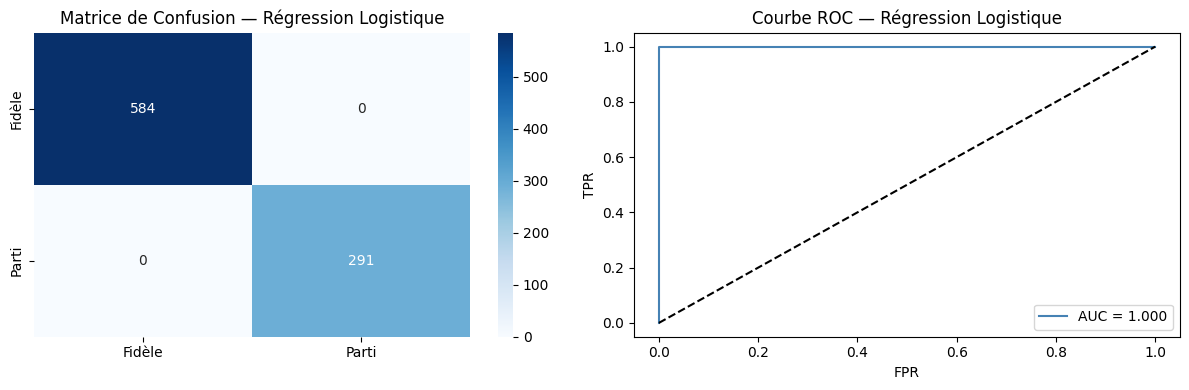

1.0

In [14]:
# Régression Logistique
lr = train_logistic_regression(X_train_scaled, y_train)
evaluate_classifier(lr, X_test_scaled, y_test,
                    model_name='Régression Logistique',
                    save_path='../reports/eval_logistic.png')

✅ Random Forest — AUC CV : 1.0000

📊 ÉVALUATION — Random Forest
              precision    recall  f1-score   support

      Fidèle       1.00      1.00      1.00       584
       Parti       1.00      1.00      1.00       291

    accuracy                           1.00       875
   macro avg       1.00      1.00      1.00       875
weighted avg       1.00      1.00      1.00       875

AUC-ROC : 1.0000


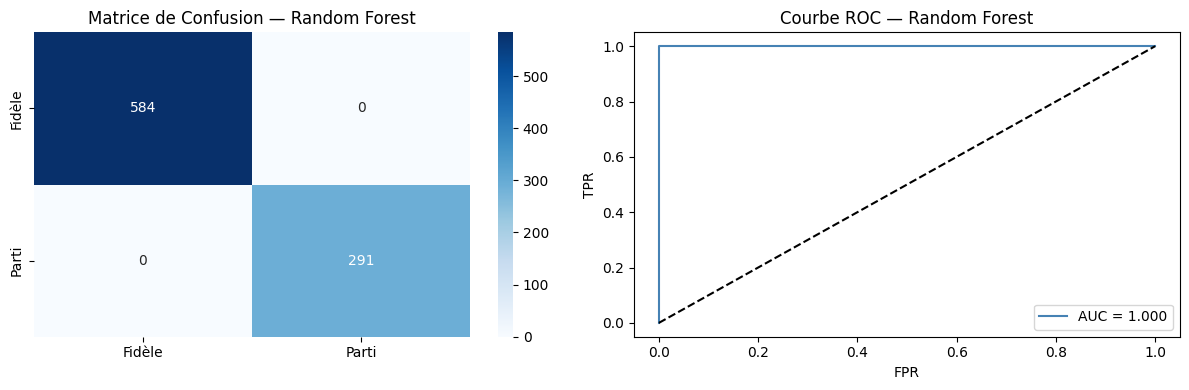

1.0

In [15]:
# Random Forest (sans GridSearch d'abord pour aller vite)
rf = train_random_forest(X_train_scaled, y_train, use_gridsearch=False)
evaluate_classifier(rf, X_test_scaled, y_test,
                    model_name='Random Forest',
                    save_path='../reports/eval_rf.png')

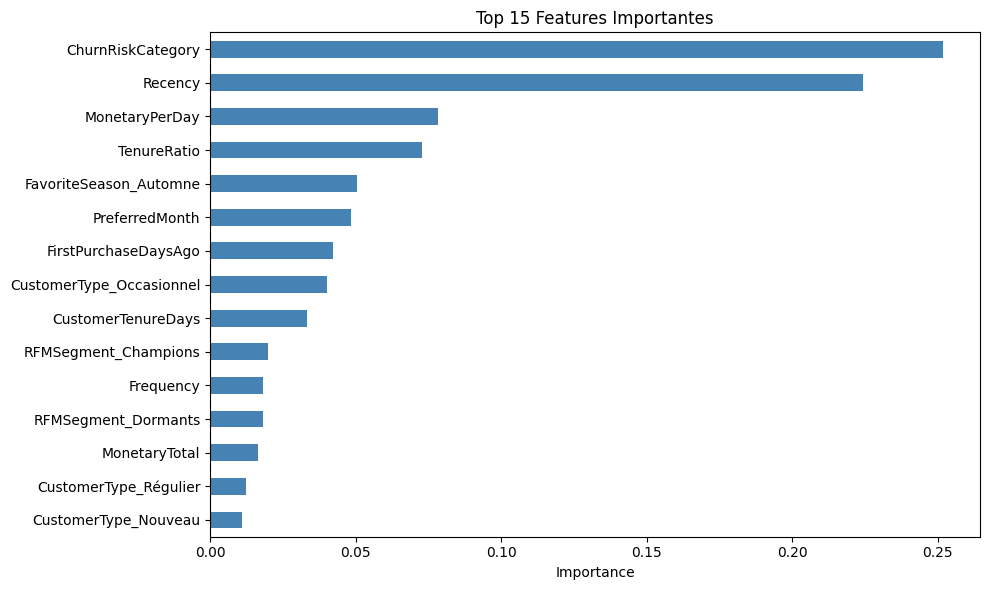

In [16]:
# Importance des features
plot_feature_importance(rf, list(X_train_scaled.columns),
                        top_n=15, save_path='../reports/feature_importance.png')

In [ ]:
# [OPTIONNEL] GridSearch Random Forest — plus lent (~5 min)
# rf_best = train_random_forest(X_train_scaled, y_train, use_gridsearch=True)
# evaluate_classifier(rf_best, X_test_scaled, y_test, model_name='RF GridSearch')

## 📈 ÉTAPE 6 — Régression : Prédiction du Montant Total

✅ Régression Ridge entraînée — sauvegardée dans models/ridge_regression.pkl

📊 ÉVALUATION RÉGRESSION — Ridge Regression
  RMSE : 0.54
  R²   : 0.6653


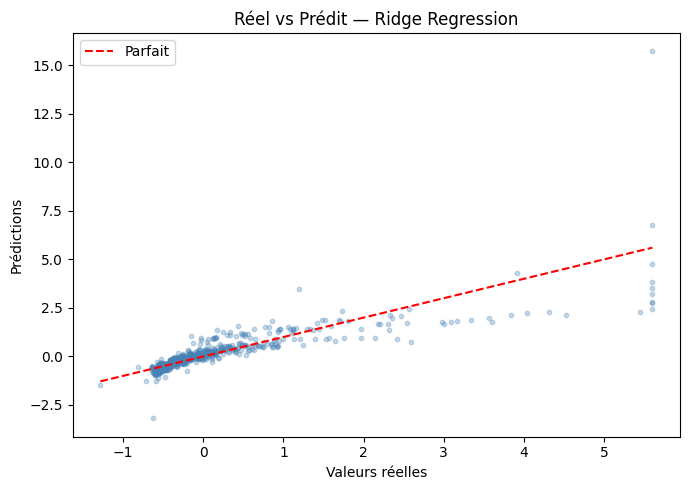

In [17]:
# Préparation target régression
# On enlève MonetaryTotal de X et on l'utilise comme y_reg
if 'MonetaryTotal' in X_train_scaled.columns:
    y_train_reg = X_train_scaled['MonetaryTotal']
    y_test_reg  = X_test_scaled['MonetaryTotal']
    X_train_reg = X_train_scaled.drop(columns=['MonetaryTotal'])
    X_test_reg  = X_test_scaled.drop(columns=['MonetaryTotal'])

    ridge = train_regression(X_train_reg, y_train_reg)
    evaluate_regression(ridge, X_test_reg, y_test_reg,
                        model_name='Ridge Regression',
                        save_path='../reports/eval_regression.png')
else:
    print('⚠️  MonetaryTotal a été supprimée (corrélation). Utiliser une autre target.')

## 📋 ÉTAPE 7 — Résumé & Recommandations

In [18]:
print('='*60)
print('📋 RÉSUMÉ DES MODÈLES ENTRAÎNÉS')
print('='*60)
print('Modèles sauvegardés dans models/')
import glob
for f in glob.glob('../models/*.pkl'):
    print(f'  ✅ {f}')
print('\nRapports dans reports/')
for f in glob.glob('../reports/*.png'):
    print(f'  📊 {f}')

📋 RÉSUMÉ DES MODÈLES ENTRAÎNÉS
Modèles sauvegardés dans models/
  ✅ ../models\scaler.pkl

Rapports dans reports/
  📊 ../reports\churn_distribution.png
  📊 ../reports\clusters_pca.png
  📊 ../reports\correlation_heatmap.png
  📊 ../reports\distributions.png
  📊 ../reports\elbow.png
  📊 ../reports\eval_logistic.png
  📊 ../reports\eval_regression.png
  📊 ../reports\eval_rf.png
  📊 ../reports\feature_importance.png
  📊 ../reports\missing_values.png
  📊 ../reports\pca_2d.png
  📊 ../reports\pca_variance.png
